1.Data Preprocessing

In [7]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values
train_images, test_images = train_images / 255.0, test_images / 255.0

# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

2.CNN model implementation.

In [8]:
model = models.Sequential([
    # Layer 1: Convolution + ReLU + Pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Layer 2: Convolution + ReLU + Pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 3: Convolution + ReLU (Deeper CNN Bonus)
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Bonus: Dropout
    layers.Dense(10, activation='softmax') # Output layer
])

3&5.Model training and visualization

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 44ms/step - accuracy: 0.4168 - loss: 1.5945 - val_accuracy: 0.5103 - val_loss: 1.3293
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.5571 - loss: 1.2481 - val_accuracy: 0.6004 - val_loss: 1.1163
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.6058 - loss: 1.1163 - val_accuracy: 0.6358 - val_loss: 1.0295
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.6381 - loss: 1.0245 - val_accuracy: 0.6524 - val_loss: 0.9782
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6646 - loss: 0.9511 - val_accuracy: 0.6773 - val_loss: 0.9164
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6851 - loss: 0.8992 - val_accuracy: 0.6796 - val_loss: 0.9106
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7022 - loss: 0.8574 - val_accuracy: 0.6867 - val_loss: 0.8958
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.7148 -

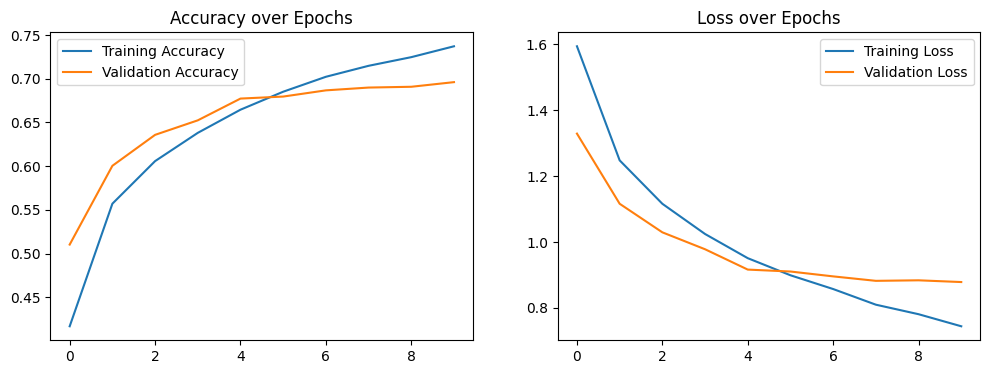

In [9]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train for 10 epochs
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# Visualization
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()

plot_history(history)

4.Evaluation

313/313 - 4s - 12ms/step - accuracy: 0.6961 - loss: 0.8786

Test Accuracy: 0.6961
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


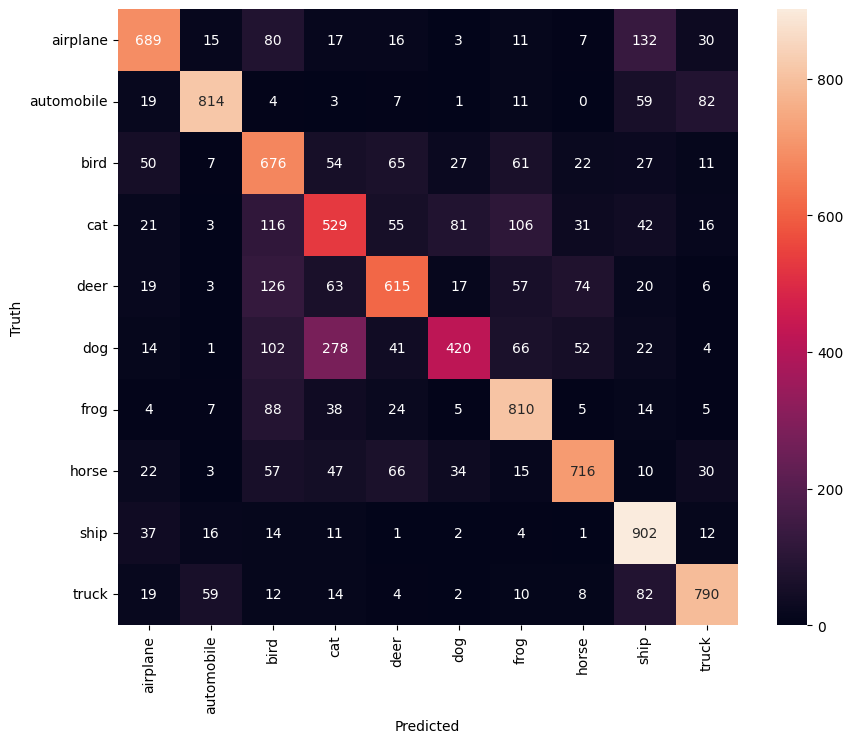

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest Accuracy: {test_acc:.4f}')

# Confusion Matrix
y_pred = np.argmax(model.predict(test_images), axis=1)
cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()